# WARP


1. 可直接实验的超参数（通过 `--param` 指定）

📦 索引构建参数（影响索引大小、压缩精度和聚类质量）

这些参数在 `index_from_embeddings.py` 中使用。修改它们需要**重新构建索引**（脚本会自动为每个值创建独立的索引文件夹）。

| 参数名 (`--param`) | 对应原始脚本参数 | 作用与权衡影响 |
| :--- | :--- | :--- |
| **`nbits`** | `--nbits` | **残差量化比特数**（1/2/4/8）。值越大，索引越大（QPS略降），但 Recall/MRR 显著提升（决定精度上限）。 |
| **`max_partitions`** | `--max-partitions` | **IVF聚类中心数上限**。值越大，聚类越细，召回上限更高，但候选生成阶段开销略增。 |
| **`sample_per_centroid`** | `--sample-per-centroid` | **每个聚类中心的训练样本数**。增大可提升聚类质量（Recall提升），但索引构建变慢，不影响在线QPS。 |
| **`max_sample_embeddings`** | `--max-sample-embeddings` | **K-Means训练的最大采样总数**。硬上限，影响聚类代表性。 |
| **`kmeans_iters`** | `--kmeans-iters` | **K-Means迭代次数**。迭代越多，聚类越收敛（Recall微升），仅影响构建时间。 |
| **`query_maxlen`** | `--query-maxlen` | 查询最大Token长度（截断）。影响查询编码形状。 |
| **`doc_maxlen`** | `--doc-maxlen` | 文档最大Token长度（截断）。影响索引嵌入总数。 |
| **`seed`** | `--seed` | 随机种子。影响K-Means初始化和采样，用于复现实验。 |

---

🚀 检索执行参数（直接决定 QPS-Accuracy 权衡曲线）

这些参数在 `sweep_ncells.py` 中使用。**不需要重新构建索引**，脚本只会构建一次基础索引，然后逐个参数值运行检索。

| 参数名 (`--param`) | 对应原始脚本参数 | 作用与权衡影响 |
| :--- | :--- | :--- |
| **`ncells`** | `--ncells`（即论文 \( n_{\text{probe}} \)） | **最重要的权衡旋钮**。访问的聚类中心数。增大则 QPS 下降，但 Recall/MRR 急剧上升（边际递减）。 |
| **`ndocs`** | `--ndocs` | 每个聚类取出的文档数。增大候选池，提升 Recall（尤其高召回场景），略微降低 QPS。 |
| **`centroid_score_threshold`** | `--centroid-score-threshold`（论文 \( t' \)） | **WARP SELECT** 中的缺失相似度估计阈值。调整几乎不损耗 QPS，但能提升 MRR/Recall（“免费午餐”）。 |

---

2. 脚本中固定（硬编码）但可调整的参数

如果你希望实验以下参数，它们被定义为脚本开头的**全局变量**（如 `FIXED_K`），你可以直接修改脚本中的数值，或稍加改造将其加入 `--param` 解析逻辑：

| 固定变量名 | 默认值 | 对应意义 | 修改建议 |
| :--- | :--- | :--- | :--- |
| `FIXED_K` | `1000` | 检索返回的候选文档数（`sweep_ncells` 的 `--k`）。 | 若想扫描该值，可在脚本中将其改为变量并加入 `RETRIEVAL_PARAMS`。 |
| `FIXED_METRICS_K` | `[100]` | 计算的指标截断值（目前只算 Recall@100 和 MRR@100）。 | 改为 `[10, 100]` 可同时输出 @10 指标。 |
| `FIXED_CHUNK_SIZE` | `50000` | 索引分块大小（影响构建内存峰值和 I/O）。 | 属于索引参数，若想实验可移至 `INDEX_PARAMS`。 |
| `FIXED_NCELLS` | `8` | 当**不扫描** `ncells` 时（如扫描 `ndocs` 时）使用的固定值。 | 可直接修改。 |

---


ncells

In [ ]:
export WARP_EMBEDDING_ROOT=/data1/chenyifeng/MultiVector-Backup/WARP/embeddings/colbert
export WARP_DATASET_ROOT=/data1/chenyifeng/Data_backup/scidocs/beir
export WARP_INDEX_ROOT=/data1/chenyifeng/MultiVector-Backup/WARP/indexes

In [ ]:
python WARPrunner.py --dataset scidocs --param ncells --values 1,2,4,6,8,10,12,14,16,20,24,32

In [ ]:
export DATASET=scidocs
export EMBEDDING_DIR=/data1/chenyifeng/Data_backup/scidocs/colbert
export INDEX_ROOT=/data1/chenyifeng/MultiVector-Backup/WARP/indexes
export INDEX_NAME=beir-scidocs.split=test.precomputed=colbert.nbits=2.2048
export CXX=/usr/bin/g++-9   

python utility/index_from_embeddings.py \
  --dataset "$DATASET" \
  --embedding-dir "$EMBEDDING_DIR" \
  --index-root "$INDEX_ROOT" \
  --index-name "$INDEX_NAME" \
  --nbits 2 \
  --threads 48 \
  --max-partitions 2048 \
  --sample-per-centroid 64 \
  --max-sample-embeddings 2000000 \
  --chunk-size 50000


export TORCH_NUM_THREADS=1
export OMP_NUM_THREADS=1

python utility/sweep_ncells.py \
  --dataset scidocs \
  --dataset-dir /data1/chenyifeng/Data_backup/scidocs/beir \
  --embedding-dir /data1/chenyifeng/Data_backup/scidocs/colbert \
  --index-root /data1/chenyifeng/MultiVector-Backup/WARP/indexes \
  --index beir-scidocs.split=test.precomputed=colbert.nbits=2 \
  --split test \
  --nbits 2 \
  --k 100 \
  --baseline warp_precomputed_colbert_nbits2_thr0.5_ndocs256 \
  --centroid-score-threshold 0.4 \
  --ndocs 4096 \
  --ncells 1 2 4 6 8 10 12 14 16 18 20 \
  --output-csv /data1/chenyifeng/MultiVector-Backup/WARP/my_runs/scidocs_colbert_thr0.5_ndocs4096.csv

above back-up

---

In [ ]:
# plot

%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt
import os

def plot_qps_metrics_log(csv_file):
    """
    从 CSV 文件读取数据，绘制 QPS 与 MRR@100、Recall@100 的关系图（X 轴为对数刻度）。

    参数:
        csv_file (str): CSV 文件的路径，必须包含 'ncells', 'qps', 'mrr_100', 'recall_100' 列。
    
    返回:
        None，但会在 CSV 同目录下保存 PNG 图片并显示图表。
    """
    # 读取数据
    df = pd.read_csv(csv_file)
    
    # 按 ncells 升序排序（使曲线连贯）
    df_sorted = df.sort_values('ncells')
    
    qps = df_sorted['qps']
    mrr_100 = df_sorted['mrr_100']
    recall_100 = df_sorted['recall_100']
    
    # 创建上下两个子图
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
    
    ax1.plot(qps, mrr_100, marker='o', linestyle='-', color='b', label='MRR@100')
    ax1.set_ylabel('MRR@100')
    ax1.set_title('QPS vs MRR@100')
    ax1.grid(True)
    ax1.legend()
    
    ax2.plot(qps, recall_100, marker='s', linestyle='-', color='r', label='Recall@100')
    ax2.set_xlabel('QPS (Queries Per Second)')
    ax2.set_ylabel('Recall@100')
    ax2.set_title('QPS vs Recall@100')
    ax2.grid(True)
    ax2.legend()
    
    # 设置 X 轴为对数刻度并指定刻度位置和标签
    ax1.set_xscale('log')
    ax2.set_xscale('log')
    ax1.set_xticks([1, 10, 100, 1000])
    ax1.set_xticklabels(['$10^0$', '$10^1$', '$10^2$', '$10^3$'])
    
    plt.tight_layout()
    
    # 保存图片（与 CSV 同目录，同名 .png）
    dir_name = os.path.dirname(csv_file)
    base_name = os.path.basename(csv_file)
    name_without_ext = os.path.splitext(base_name)[0]
    save_path = os.path.join(dir_name, name_without_ext + '.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"图片已保存至：{save_path}")
    
    plt.show()

## Scidocs

In [ ]:
# Build a WARP Index

cd WARP

export DATASET=scidocs
export EMBEDDING_DIR=/data1/chenyifeng/Data_backup/scidocs/colbert
export INDEX_ROOT=/data1/chenyifeng/MultiVector-Backup/WARP/indexes
export INDEX_NAME=beir-scidocs.split=test.precomputed=colbert.nbits=2
export CXX=/usr/bin/g++-9   

python utility/index_from_embeddings.py \
  --dataset "$DATASET" \
  --embedding-dir "$EMBEDDING_DIR" \
  --index-root "$INDEX_ROOT" \
  --index-name "$INDEX_NAME" \
  --nbits 2 \
  --threads 48 \
  --max-partitions 32768 \
  --sample-per-centroid 64 \
  --max-sample-embeddings 2000000 \
  --chunk-size 50000

In [ ]:
# Run WARP Search

cd WARP

export TORCH_NUM_THREADS=1
export OMP_NUM_THREADS=1

python utility/sweep_ncells.py \
  --dataset scidocs \
  --dataset-dir /data1/chenyifeng/Data_backup/scidocs/beir \
  --embedding-dir /data1/chenyifeng/Data_backup/scidocs/colbert \
  --index-root /data1/chenyifeng/MultiVector-Backup/WARP/indexes \
  --index beir-scidocs.split=test.precomputed=colbert.nbits=2 \
  --split test \
  --nbits 2 \
  --k 100 \
  --baseline warp_precomputed_colbert_nbits2_thr0.5_ndocs256 \
  --centroid-score-threshold 0.5 \
  --ndocs 256 \
  --ncells 1 2 4 8 16 32 64 128 256 512\
  --output-csv /data1/chenyifeng/MultiVector-Backup/WARP/my_runs/scidocs_colbert_thr0.5_ndocs256.csv

# 1 2 3 4

图片已保存至：/data1/chenyifeng/MultiVector-Backup/WARP/my_runs/scidocs_colbert_thr0.5_ndocs256.png


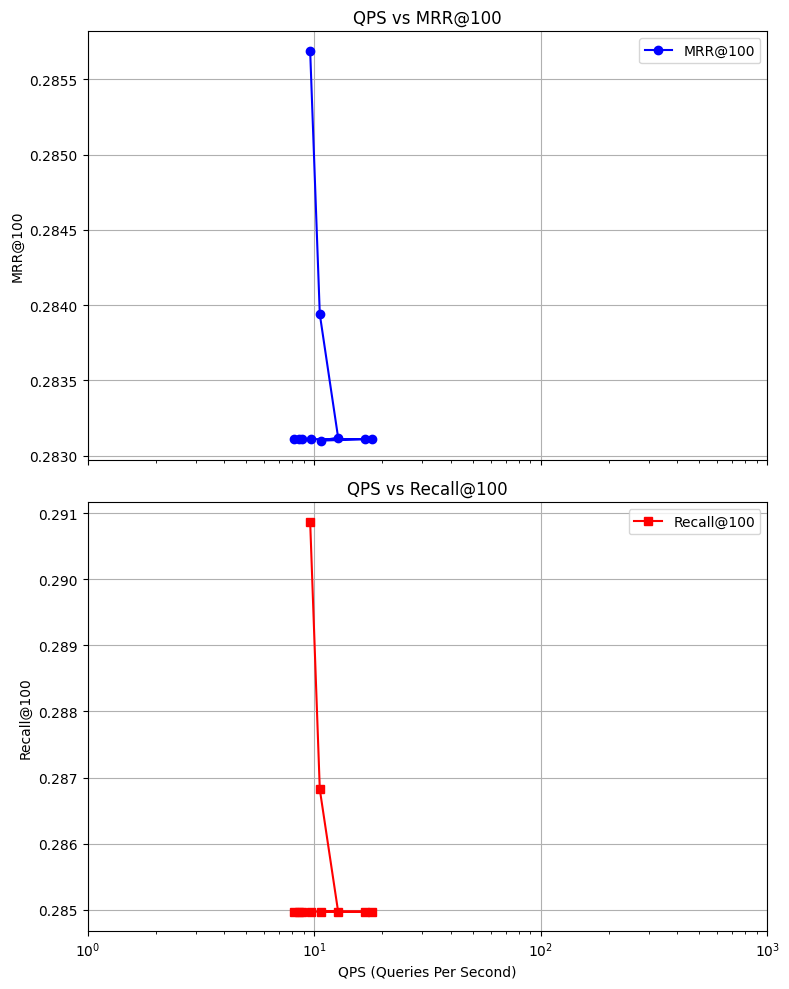

In [ ]:
# plot

plot_qps_metrics_log('/data1/chenyifeng/MultiVector-Backup/WARP/my_runs/scidocs_colbert_thr0.5_ndocs256.csv')

## Fiqa

In [ ]:
cd WARP

bash run_fiqa.sh

图片已保存至：/data1/chenyifeng/MultiVector-Backup/WARP/my_runs/scidocs_colbert_thr0.5_ndocs256.png


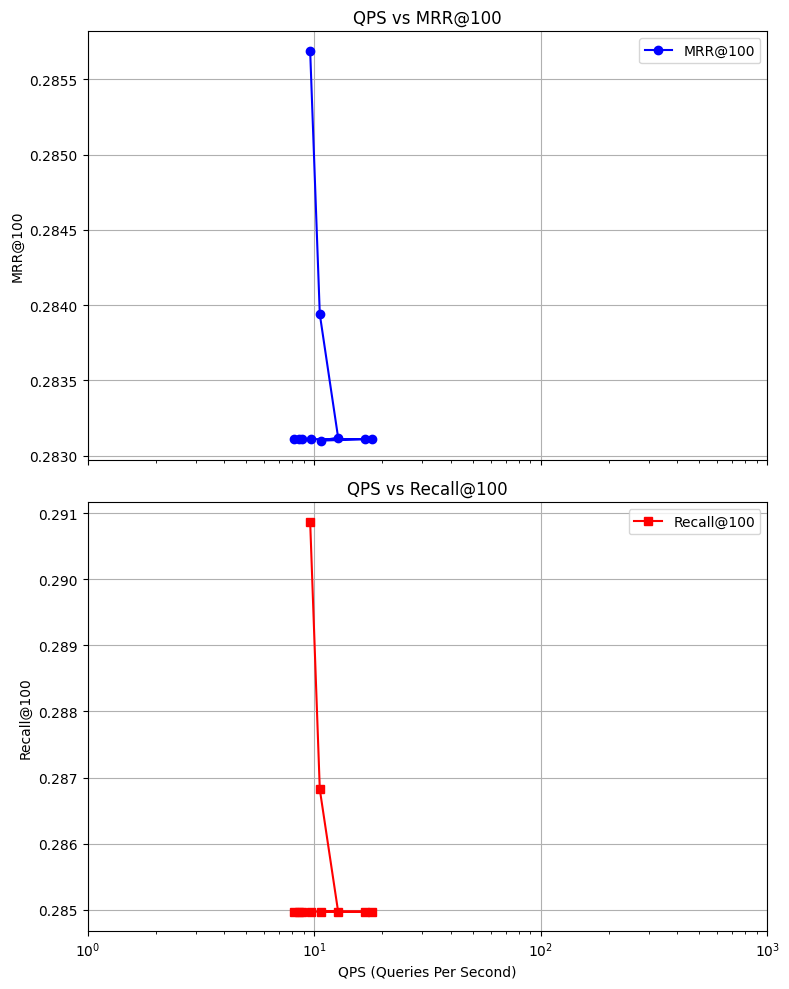

In [ ]:
# plot

plot_qps_metrics_log('/data1/chenyifeng/MultiVector-Backup/WARP/my_runs/scidocs_colbert_thr0.5_ndocs256.csv')